In [1470]:
import glob
import fitsio
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import scienceplots
plt.style.use(['science', 'notebook', 'grid']) 
from scipy.optimize import curve_fit 
from sklearn.linear_model import LinearRegression

In [1471]:
def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m

In [1472]:
systematics_list_debug = ['H_Alpha','Saggitarius_Density', 'Stellar_Density_AllWISE', 'CSFD', 'EBV','PSFDEPTH_Z','PSFDEPTH_G','PSFDEPTH_R','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','PSFDEPTH_W1','PSFDEPTH_W2','H_Alpha_Good','PSFDEPTH_Z_RAW','PSFDEPTH_G_RAW','PSFDEPTH_R_RAW']
systematics_list = ['H_Alpha','Saggitarius_Density', 'Stellar_Density_AllWISE', 'CSFD','PSFDEPTH_Z','PSFDEPTH_G','PSFDEPTH_R','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','PSFDEPTH_W1']
#systematics_list = ['H_Alpha','Saggitarius_Density', 'Stellar_Density_AllWISE', 'CSFD','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','PSFDEPTH_W1']

#systematics_list = ['CSFD']
path = 'imaging_systematics_maps/data/'
part= 'south'
mask =hp.read_map(f'{path}/{part}_mask_nside_64_for_systmatics_20M.fits')
randoms_counts = hp.read_map(f'{path}/{part}_counts_randoms_nside_64.fits')
systematics_maps = {}
for sys_name in systematics_list:
    sys_map = hp.read_map(f'{path}/{part}_{sys_name}_nside_64.fits')
    #sys_map[mask==0] = hp.UNSEEN
    #hp.mollview(sys_map, title=sys_name, unit='', cmap='YlGnBu')
    systematics_maps[sys_name] = sys_map
    data  =sys_map[mask>0]
    # plt.hist(data, bins=100, alpha=0.7)
    # plt.title(sys_name)
    # plt.xlabel('Value')
    # plt.ylabel('Counts')
    # plt.show()
data = Table(fitsio.FITS('../../table_match_final.fits')[1].read())
if part=='north':
    data = data[data['DEC']>=32.3]
elif part=='south':
    data = data[data['DEC']<32.3]
data = points_to_map(data['RA'], data['DEC'], nside=64)

remove_outliers = True
if remove_outliers:
    kind = 'equal'  # equal or partial_percentile
    val = 10



In [1473]:
ll0

0.05

no lower limit
Number of elements removed for  H_Alpha :  34655
no lower limit
Number of elements removed for  Saggitarius_Density :  34643
Number of elements removed for  Stellar_Density_AllWISE :  34776
no lower limit
Number of elements removed for  CSFD :  34522
Number of elements removed for  PSFDEPTH_Z :  35494
Number of elements removed for  PSFDEPTH_G :  35951
Number of elements removed for  PSFDEPTH_R :  36095
Number of elements removed for  PSFSIZE_G :  35736
Number of elements removed for  PSFSIZE_R :  35740
Number of elements removed for  PSFSIZE_Z :  35266
Number of elements removed for  PSFDEPTH_W1 :  35141


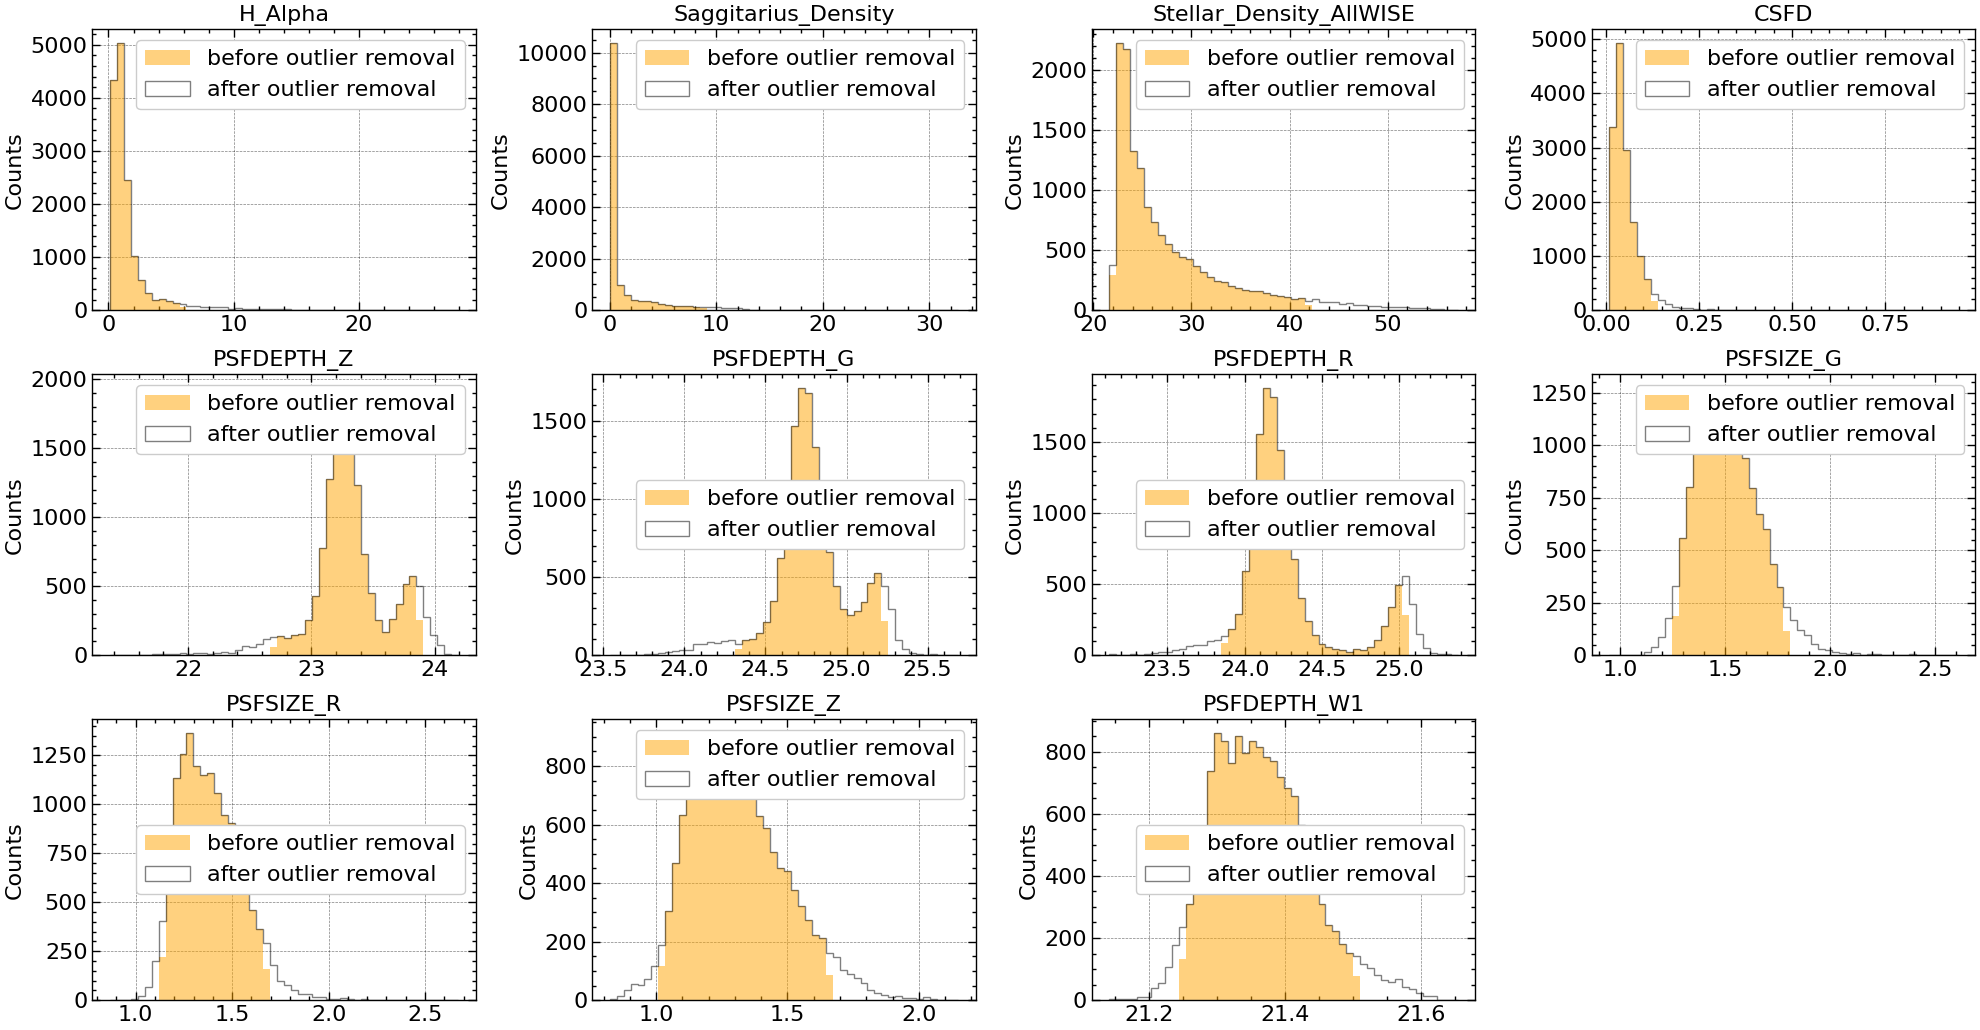

In [1474]:
#removing outliers systematics
if remove_outliers:
    masks  = []
    limits = []
    
    # Calculate number of rows needed for subplots
    n_sys = len(systematics_list)
    n_cols = 4
    n_rows = (n_sys + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5*n_rows))
    axes = axes.flatten()
    
    for idx, sys_name in enumerate(systematics_list):
        sys_map = systematics_maps[sys_name]
        valid = (mask>0) & np.isfinite(sys_map)
        counts, bin_edges = np.histogram(sys_map[valid], bins=50)
        frac_area = counts/np.sum(counts)
        bin_centers = (bin_edges[:-1]+bin_edges[1:])/2
        order = np.argsort(bin_centers)
        cumfrac = np.cumsum(frac_area[order])
        cum_mask = np.zeros_like(frac_area, dtype=bool)
        cum_mask[order] = (cumfrac >=0.025) & (cumfrac <=0.975)
        if kind == 'equal':
            ul0 = (1-val/100/2)
            ll0 = (val/100/2)

            ul = np.min(bin_centers[(cumfrac >ul0)])
            try:
                ll = np.max(bin_centers[(cumfrac <ll0)])
            except:
                print('no lower limit')
                ll = np.min(sys_map[valid])
        elif kind == 'partial_percentile':
            if sys_name == 'CSFD' or sys_name == 'Saggitarius_Density' or sys_name == 'Stellar_Density_AllWISE' or sys_name == 'H_Alpha':
                ul =  np.min(bin_centers[(cumfrac >0.95)])
            else:
                ul =  np.min(bin_centers[(cumfrac >=0.99)])
            try:
                ll = np.max(bin_centers[(cumfrac <0.01)])
            except:
                print('no lower limit')
                ll = np.min(sys_map[valid])

        
        removal_mask = (sys_map >=ll) & (sys_map<=ul)
        usable_maps = sys_map[removal_mask]
        
        limits.append((ll, ul))
        print('Number of elements removed for ', sys_name, ': ', np.sum(~removal_mask ))
        
        axes[idx].hist(usable_maps, bins=bin_edges, alpha=0.5, label=f'before outlier removal', color='orange')
        axes[idx].hist(sys_map[valid], bins=bin_edges, alpha=0.5, label=f'after outlier removal', color='k', histtype='step')
        axes[idx].legend()
        axes[idx].set_title(f'{sys_name}')
        axes[idx].set_ylabel('Counts')
        
        masks.append(removal_mask)
    
    # Hide unused subplots
    for idx in range(n_sys, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    combined_masks = np.all(np.array(masks), axis=0)
else:
    combined_masks = mask>0


In [1475]:
# masks  = []
# limits = []
# for sys_name in systematics_list:
#     sys_map = systematics_maps[sys_name]
#     valid = (mask>0)
#     plt.hist(sys_map[combined_masks&valid], alpha=0.5, label=f'{sys_name} after outlier removal',color='k',histtype='step')
#     plt.title(f'Histogram of {sys_name} before outlier removal')
#     plt.show()

In [1476]:
max_count = randoms_counts[mask==1].max()
tr = 0.0
normalized_counts = randoms_counts / max_count

randoms_counts_subtracted =np.where(normalized_counts>tr, randoms_counts, 0)

num_outside = len(normalized_counts[mask==1][normalized_counts[mask==1]<tr])
print(f'Number of pixels outside {tr}: {num_outside}, out of {len(normalized_counts[mask==1])} total pixels')

data_counts_subtracted = np.where(normalized_counts>tr, data, 0)

ngal = data_counts_subtracted[mask==1]
nran = randoms_counts_subtracted[mask==1]
pix64 = np.where(mask==1)[0]

Number of pixels outside 0.0: 0, out of 15227 total pixels


In [1477]:
##removing outliers systematics
ngal = ngal[combined_masks[mask==1]]
nran = nran[combined_masks[mask==1]]
pix64 = pix64[combined_masks[mask==1]]

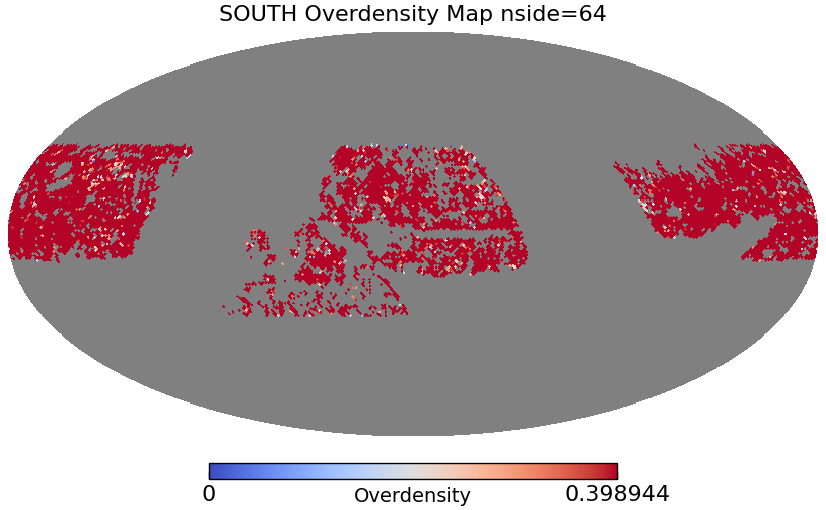

In [1478]:
valid = np.isfinite(ngal) & np.isfinite(nran) & (nran > 0)  & (ngal > 0)
ngal_valid = ngal[valid]
nran_valid = nran[valid]
overdensity_maps  = ngal_valid/nran_valid * np.sum(nran_valid)/np.sum(ngal_valid) 

sigma_overdensity = np.sqrt(ngal_valid)/nran_valid * np.sum(nran_valid)/np.sum(ngal_valid)

finite_masks = {}
sys_maps_for_fit = {}
for sys_interated in systematics_list:
    temp  = hp.read_map(f'{path}/{part}_{sys_interated}_nside_64.fits')


    sys_maps_for_fit[sys_interated] = temp[mask==1][combined_masks[mask==1]][valid]
    finite_mask  = np.isfinite(temp[mask==1][combined_masks[mask==1]][valid])
    finite_masks[sys_interated] = finite_mask
    num_nan = np.sum(~finite_mask)
    if num_nan > 0:
        print(f'Systematic {sys_interated}: {num_nan} NaN values within the mask')
    

finite_mask_combined = np.all([finite_masks[sys] for sys in systematics_list],axis=0)
sys_map_for_fit_combined = np.vstack([sys_maps_for_fit[sys]-np.nanmean(sys_maps_for_fit[sys]) for sys in systematics_list]).T

tot_map = np.full(hp.nside2npix(64), np.nan)


model = LinearRegression(fit_intercept=False)

w = 1/ sigma_overdensity**2
model.fit(sys_map_for_fit_combined[finite_mask_combined], overdensity_maps[finite_mask_combined], sample_weight=w[finite_mask_combined])


overdensity_full = np.full(len(ngal), np.nan)



overdensity_full[valid] = overdensity_maps
sigma_overdensity_full = np.full(len(ngal), np.nan)
sigma_overdensity_full[valid] = sigma_overdensity
tot_map[combined_masks] = overdensity_full
#tot_map[combined_masks] = sigma_overdensity_full

hp.mollview(tot_map, title=f'{part.upper()} Overdensity Map nside=64', unit='Overdensity', cmap='coolwarm',min = 0, max = np.percentile(sigma_overdensity_full[np.isfinite(sigma_overdensity_full)],99))

Multilinear Regression Coefficients with Uncertainties:
H_Alpha                       : -0.043696 ± 0.002492
Saggitarius_Density           : -0.001552 ± 0.001102
Stellar_Density_AllWISE       : -0.004831 ± 0.000562
CSFD                          : -0.308693 ± 0.102622
PSFDEPTH_Z                    : 0.219901 ± 0.018426
PSFDEPTH_G                    : -0.235944 ± 0.021214
PSFDEPTH_R                    : -0.180004 ± 0.015611
PSFSIZE_G                     : -0.316047 ± 0.018872
PSFSIZE_R                     : -0.130077 ± 0.018806
PSFSIZE_Z                     : -0.094062 ± 0.016586
PSFDEPTH_W1                   : 0.048247 ± 0.033512


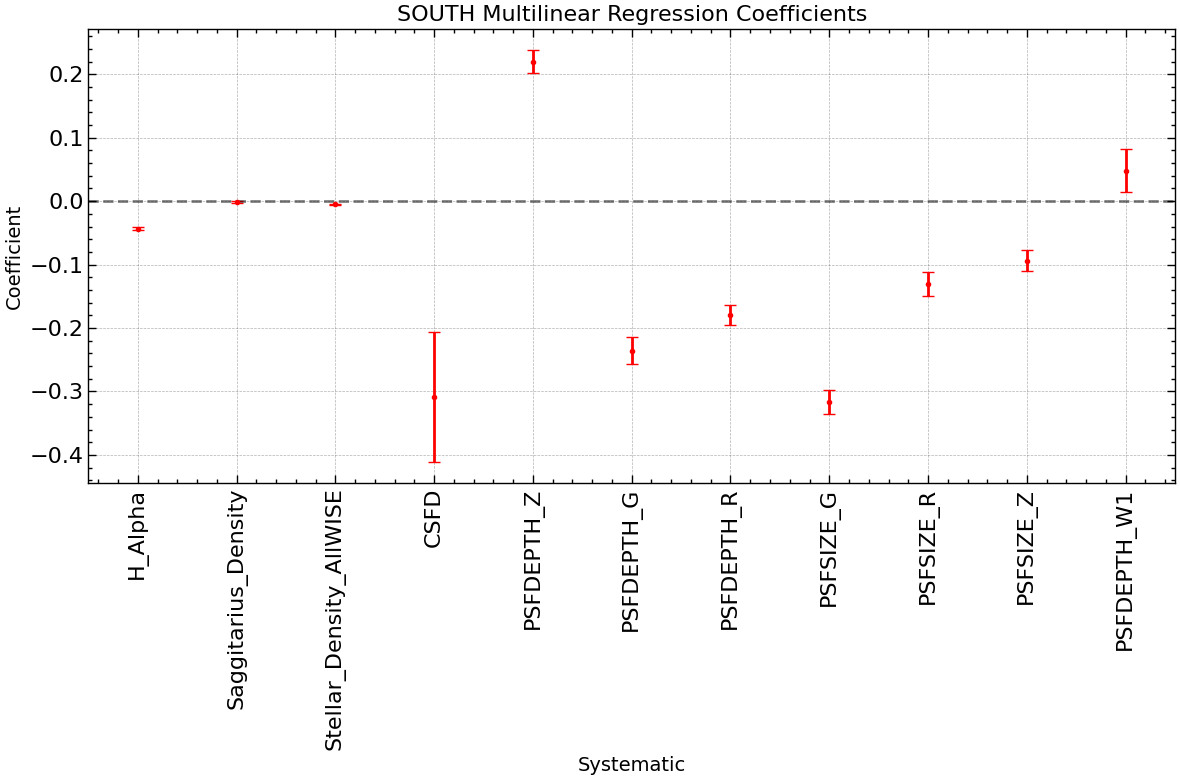

In [1479]:
# Calculate coefficient uncertainties from weighted least squares
# Using the covariance matrix approach

valid = np.isfinite(ngal) & np.isfinite(nran) & (nran > 0) & (ngal > 0)
ngal_valid = ngal[valid]
nran_valid = nran[valid]

# Compute overdensity
overdensity_maps = ngal_valid / nran_valid * np.sum(nran_valid) / np.sum(ngal_valid)

# Prepare feature matrix (centered)
sys_maps_for_fit = {}
for sys_name in systematics_list:
    temp = hp.read_map(f'{path}/{part}_{sys_name}_nside_64.fits')
    sys_maps_for_fit[sys_name] = temp[mask==1][combined_masks[mask==1]][valid]

finite_mask_combined = np.all([np.isfinite(sys_maps_for_fit[sys]) for sys in systematics_list], axis=0)
X = np.vstack([sys_maps_for_fit[sys][finite_mask_combined] - np.nanmean(sys_maps_for_fit[sys][finite_mask_combined]) 
               for sys in systematics_list]).T

y = overdensity_maps[finite_mask_combined] -1 

# Weights (inverse variance)
sigma_y = np.sqrt(ngal_valid[finite_mask_combined]) / nran_valid[finite_mask_combined] * np.sum(nran_valid) / np.sum(ngal_valid)
W = np.diag(1.0 / sigma_y**2)

# Weighted least squares: beta = (X^T W X)^-1 X^T W y
XtWX = X.T @ W @ X
XtWy = X.T @ W @ y

# Coefficients
coeffs = np.linalg.solve(XtWX, XtWy)

# Covariance matrix of coefficients
cov_matrix = np.linalg.inv(XtWX)

# Standard errors (uncertainties)
coeff_errors = np.sqrt(np.diag(cov_matrix))


print("Multilinear Regression Coefficients with Uncertainties:")
print("=" * 60)
for i, sys_name in enumerate(systematics_list):
    print(f"{sys_name:30s}: {coeffs[i]:8.6f} ± {coeff_errors[i]:.6f}")


plt.figure(figsize=(12, 8))
plt.errorbar(range(len(systematics_list)), coeffs, yerr=coeff_errors, 
             fmt='o', capsize=4, markersize=3, linewidth=2,color='r')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xticks(range(len(systematics_list)), systematics_list, rotation=90)
plt.ylabel('Coefficient', fontsize=14)
plt.xlabel('Systematic', fontsize=14)
plt.title(f'{part.upper()} Multilinear Regression Coefficients', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1480]:
if kind == 'equal':
    np.save(f'{part}_multilinear_regression_coefficients_{kind}_{val}.npy', {'coefficients': coeffs, 'errors': coeff_errors, 'systematics': systematics_list})
elif kind == 'partial_percentile':
    np.save(f'{part}_multilinear_regression_coefficients_{kind}.npy', {'coefficients': coeffs, 'errors': coeff_errors, 'systematics': systematics_list})

In [1481]:
# coeffs_north_partial_percentile = coeffs
# coeffs_error_north_partial_percentile=coeff_errors
# coeffs_south_partial_percentile = coeffs
# coeffs_error_south_partial_percentile=coeff_errors
# coeffs_full_partial_percentile = coeffs
# coeffs_error_full_partial_percentile=coeff_errors
# for part in ['north', 'south', 'full']:
#     np.savetxt(f'coeffs_{part}_partial_percentile.txt', coeffs)
#     np.savetxt(f'coeffs_error_{part}_partial_percentile.txt', coeff_errors)

# plt.figure(figsize=(12, 8))
# plt.errorbar(range(len(systematics_list)), coeffs_north_partial_percentile, yerr=coeffs_error_north_partial_percentile, 
#              fmt='o', capsize=4, markersize=3, linewidth=2,color='r',label='North')
# plt.errorbar(range(len(systematics_list)), coeffs_south_partial_percentile, yerr=coeffs_error_south_partial_percentile, 
#              fmt='o', capsize=4, markersize=3, linewidth=2,color='b',label='South')

# plt.errorbar(range(len(systematics_list)), coeffs_full_partial_percentile, yerr=coeffs_error_full_partial_percentile, 
#              fmt='o', capsize=4, markersize=3, linewidth=2,color='g',label='Full')
# plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
# plt.xticks(range(len(systematics_list)), systematics_list, rotation=90)
# plt.ylabel('Coefficient', fontsize=14)
# plt.xlabel('Systematic', fontsize=14)
# plt.title(f'Multilinear Regression Coefficients with ', fontsize=16)
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

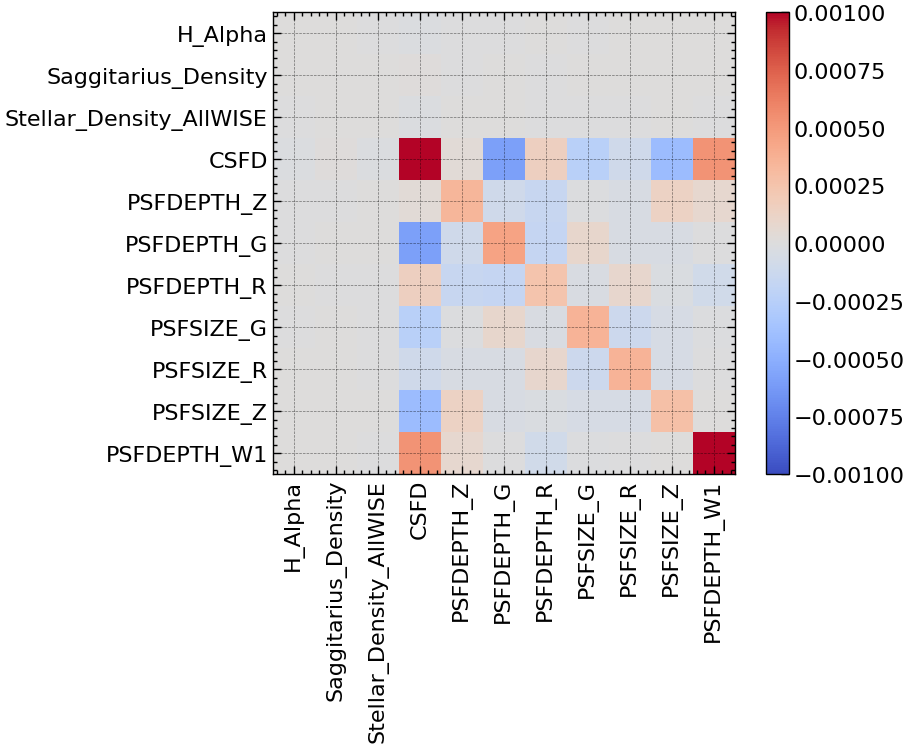

In [1482]:
plt.imshow(cov_matrix, cmap='coolwarm',vmin = -0.001,vmax = 0.001)
plt.xticks(range(len(systematics_list)), systematics_list, rotation=90)
plt.yticks(range(len(systematics_list)), systematics_list)
plt.colorbar()

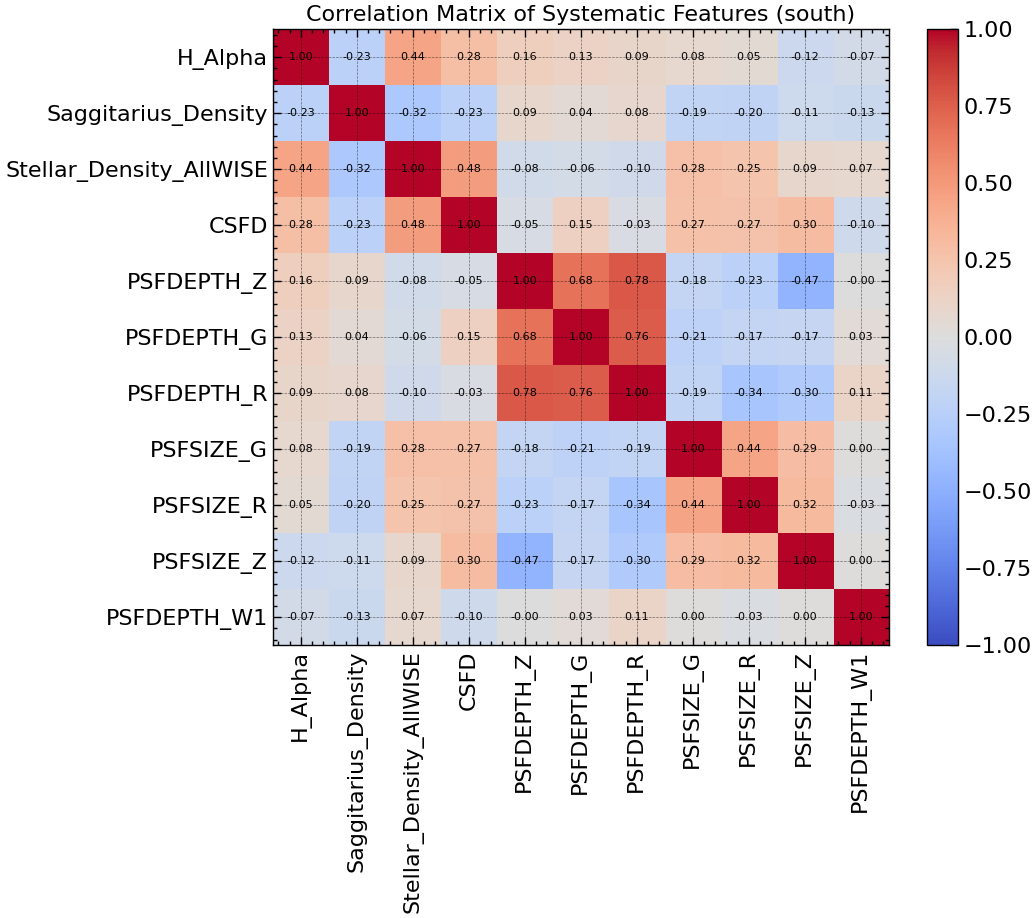

In [1483]:
corr = np.corrcoef(X, rowvar=False)
plt.figure(figsize=(10, 8))
im = plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.xticks(range(len(systematics_list)), systematics_list, rotation=90)
plt.yticks(range(len(systematics_list)), systematics_list)
plt.title(f'Correlation Matrix of Systematic Features ({part})', fontsize=16)

# Add text annotations showing correlation values
for i in range(len(systematics_list)):
    for j in range(len(systematics_list)):
        text = plt.text(j, i, f'{corr[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)
plt.colorbar()

In [1484]:
pred_overdens = X@coeffs
pred_map = np.full(hp.nside2npix(64), 1)
pix_all = np.where(mask == 1)[0]          # pixels in footprint
pix_valid = pix_all[combined_masks[mask==1]][valid]               # valid ngal/nran pixels
pix_fit = pix_valid[finite_mask_combined] # pixels used in regression
    
pred_map[pix_fit] = pred_overdens
weights = 1 / (1+pred_overdens)
weights = np.clip(weights, 0.5, 2.0)
weights = weights/np.mean(weights)

In [1485]:
pred_overdens = coeffs@X.T
pred_map = np.full(hp.nside2npix(64), np.nan)
pix_all = np.where(mask == 1)[0]          # pixels in footprint
pix_valid = pix_all[combined_masks[mask==1]][valid]               # valid ngal/nran pixels
pix_fit = pix_valid[finite_mask_combined] # pixels used in regression

pred_map[pix_fit] = pred_overdens

og_map = np.full(hp.nside2npix(64), np.nan)
og_map[pix_fit] = y

(array([3.275e+03, 3.362e+03, 8.780e+02, 1.830e+02, 7.700e+01, 2.800e+01,
        1.000e+01, 3.000e+00, 4.000e+00, 1.000e+00]),
 array([  1. ,  18.5,  36. ,  53.5,  71. ,  88.5, 106. , 123.5, 141. ,
        158.5, 176. ]),
 <BarContainer object of 10 artists>)

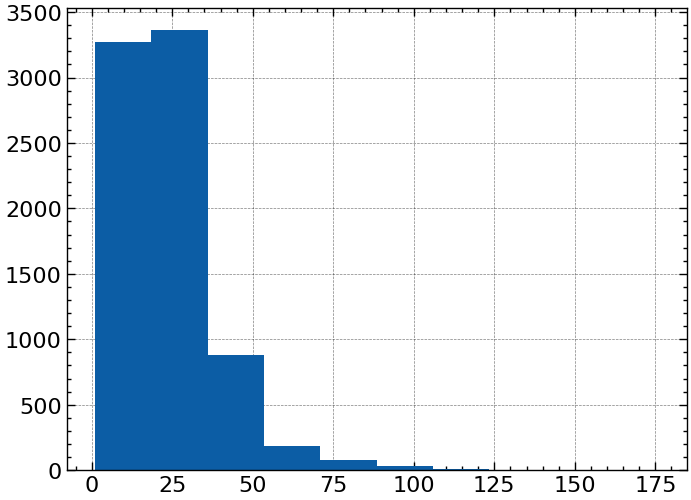

In [1486]:
plt.hist(ngal_valid)

In [1487]:
ngal_corr_valid = weights * ngal_valid


In [1488]:
pix64 =  np.where(mask==1)[0]

In [1489]:
combined_masks[mask==1]

array([False, False, False, ..., False, False, False], shape=(15227,))

In [1490]:
nside = 6
pix64_plotting = pix64[combined_masks[mask==1]][valid]
theta, phi = hp.pix2ang(64, pix64_plotting, nest=False)
jk_pix_full = hp.ang2pix(nside, theta, phi, nest=False)
_, jk_labels_full = np.unique(jk_pix_full, return_inverse=True)
len(jk_labels_full)

7821

In [1491]:
len(ngal_valid), len(nran_valid), len(data)

(7821, 7821, 49152)

In [1492]:
coeffs

array([-0.04369612, -0.00155234, -0.00483074, -0.30869313,  0.21990122,
       -0.23594412, -0.18000434, -0.31604717, -0.13007666, -0.09406215,
        0.0482471 ])

In [1493]:
from delta_sys import error_jackknife_patch, finalize_data


In [1494]:
ngal_corr_valid

array([ 1.24990184,  4.96266246,  1.22265267, ..., 30.1815132 ,
       13.04812346, 11.13402171], shape=(7821,))

In [1495]:
ngal_valid

array([ 1.,  4.,  1., ..., 28., 12., 10.], shape=(7821,))

(array([ 50., 177., 401., 740., 941., 966., 883., 750., 634., 481., 390.,
        296., 207., 201., 155., 114.,  82.,  66.,  50.,  43.,  28.,  20.,
         17.,  20.,  11.,  18.,  14.,  13.,   7.,   6.,   6.,   8.,   2.,
          1.,   5.,   2.,   2.,   0.,   5.,   1.,   0.,   0.,   0.,   1.,
          2.,   0.,   1.,   2.,   0.,   0.]),
 array([  1.  ,   3.98,   6.96,   9.94,  12.92,  15.9 ,  18.88,  21.86,
         24.84,  27.82,  30.8 ,  33.78,  36.76,  39.74,  42.72,  45.7 ,
         48.68,  51.66,  54.64,  57.62,  60.6 ,  63.58,  66.56,  69.54,
         72.52,  75.5 ,  78.48,  81.46,  84.44,  87.42,  90.4 ,  93.38,
         96.36,  99.34, 102.32, 105.3 , 108.28, 111.26, 114.24, 117.22,
        120.2 , 123.18, 126.16, 129.14, 132.12, 135.1 , 138.08, 141.06,
        144.04, 147.02, 150.  ]),
 <BarContainer object of 50 artists>)

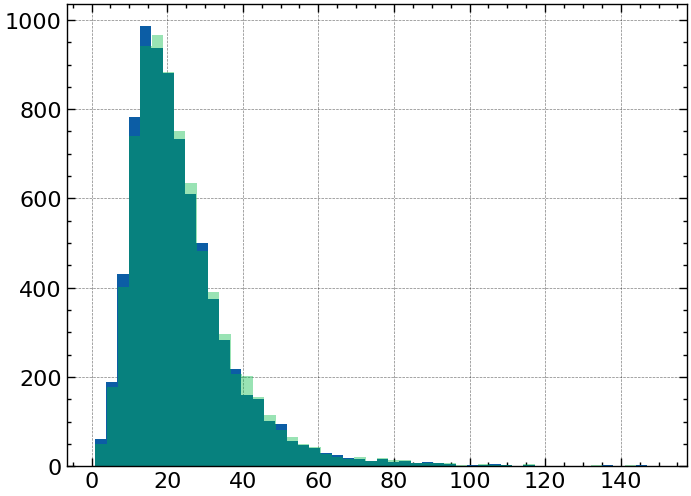

In [1496]:
plt.hist(ngal_corr_valid,bins = 50 , range=(ngal_corr_valid.min(), 150))
plt.hist(ngal_valid,bins = 50 , range=(ngal_valid.min(), 150),alpha=0.4)

lentgh of ngal: 7821, nran: 7821, features: 7821, n_jack: 149, full_vals length: 30, length of mask: 7821
[ 4562. 27479. 34915. 30595. 23848. 18338. 11223.  7660.  6011.  4093.
  3839.  2491.  2210.  2055.   971.   916.   701.   622.   210.   421.
   513.   340.   516.   450.   267.   422.   281.   291.   343.   184.]
0 14 0
lentgh of ngal: 7821, nran: 7821, features: 7821, n_jack: 149, full_vals length: 30, length of mask: 7821
[ 4099.41750401 25266.72487532 33135.12832656 30173.711941
 23957.93979877 18595.95317149 11612.90036024  7935.48389649
  6242.4553155   4370.09878483  4133.292462    2686.28031681
  2404.59263666  2145.64003962  1050.34530846   997.46733664
   812.13885693   741.50196116   226.33038123   491.30655128
   601.27849148   392.35392005   616.16362187   526.51992153
   324.48615375   515.42500866   348.77985407   353.92082735
   439.09062878   233.05333358]
0 13 0
lentgh of ngal: 7821, nran: 7821, features: 7821, n_jack: 149, full_vals length: 30, length of mask: 78

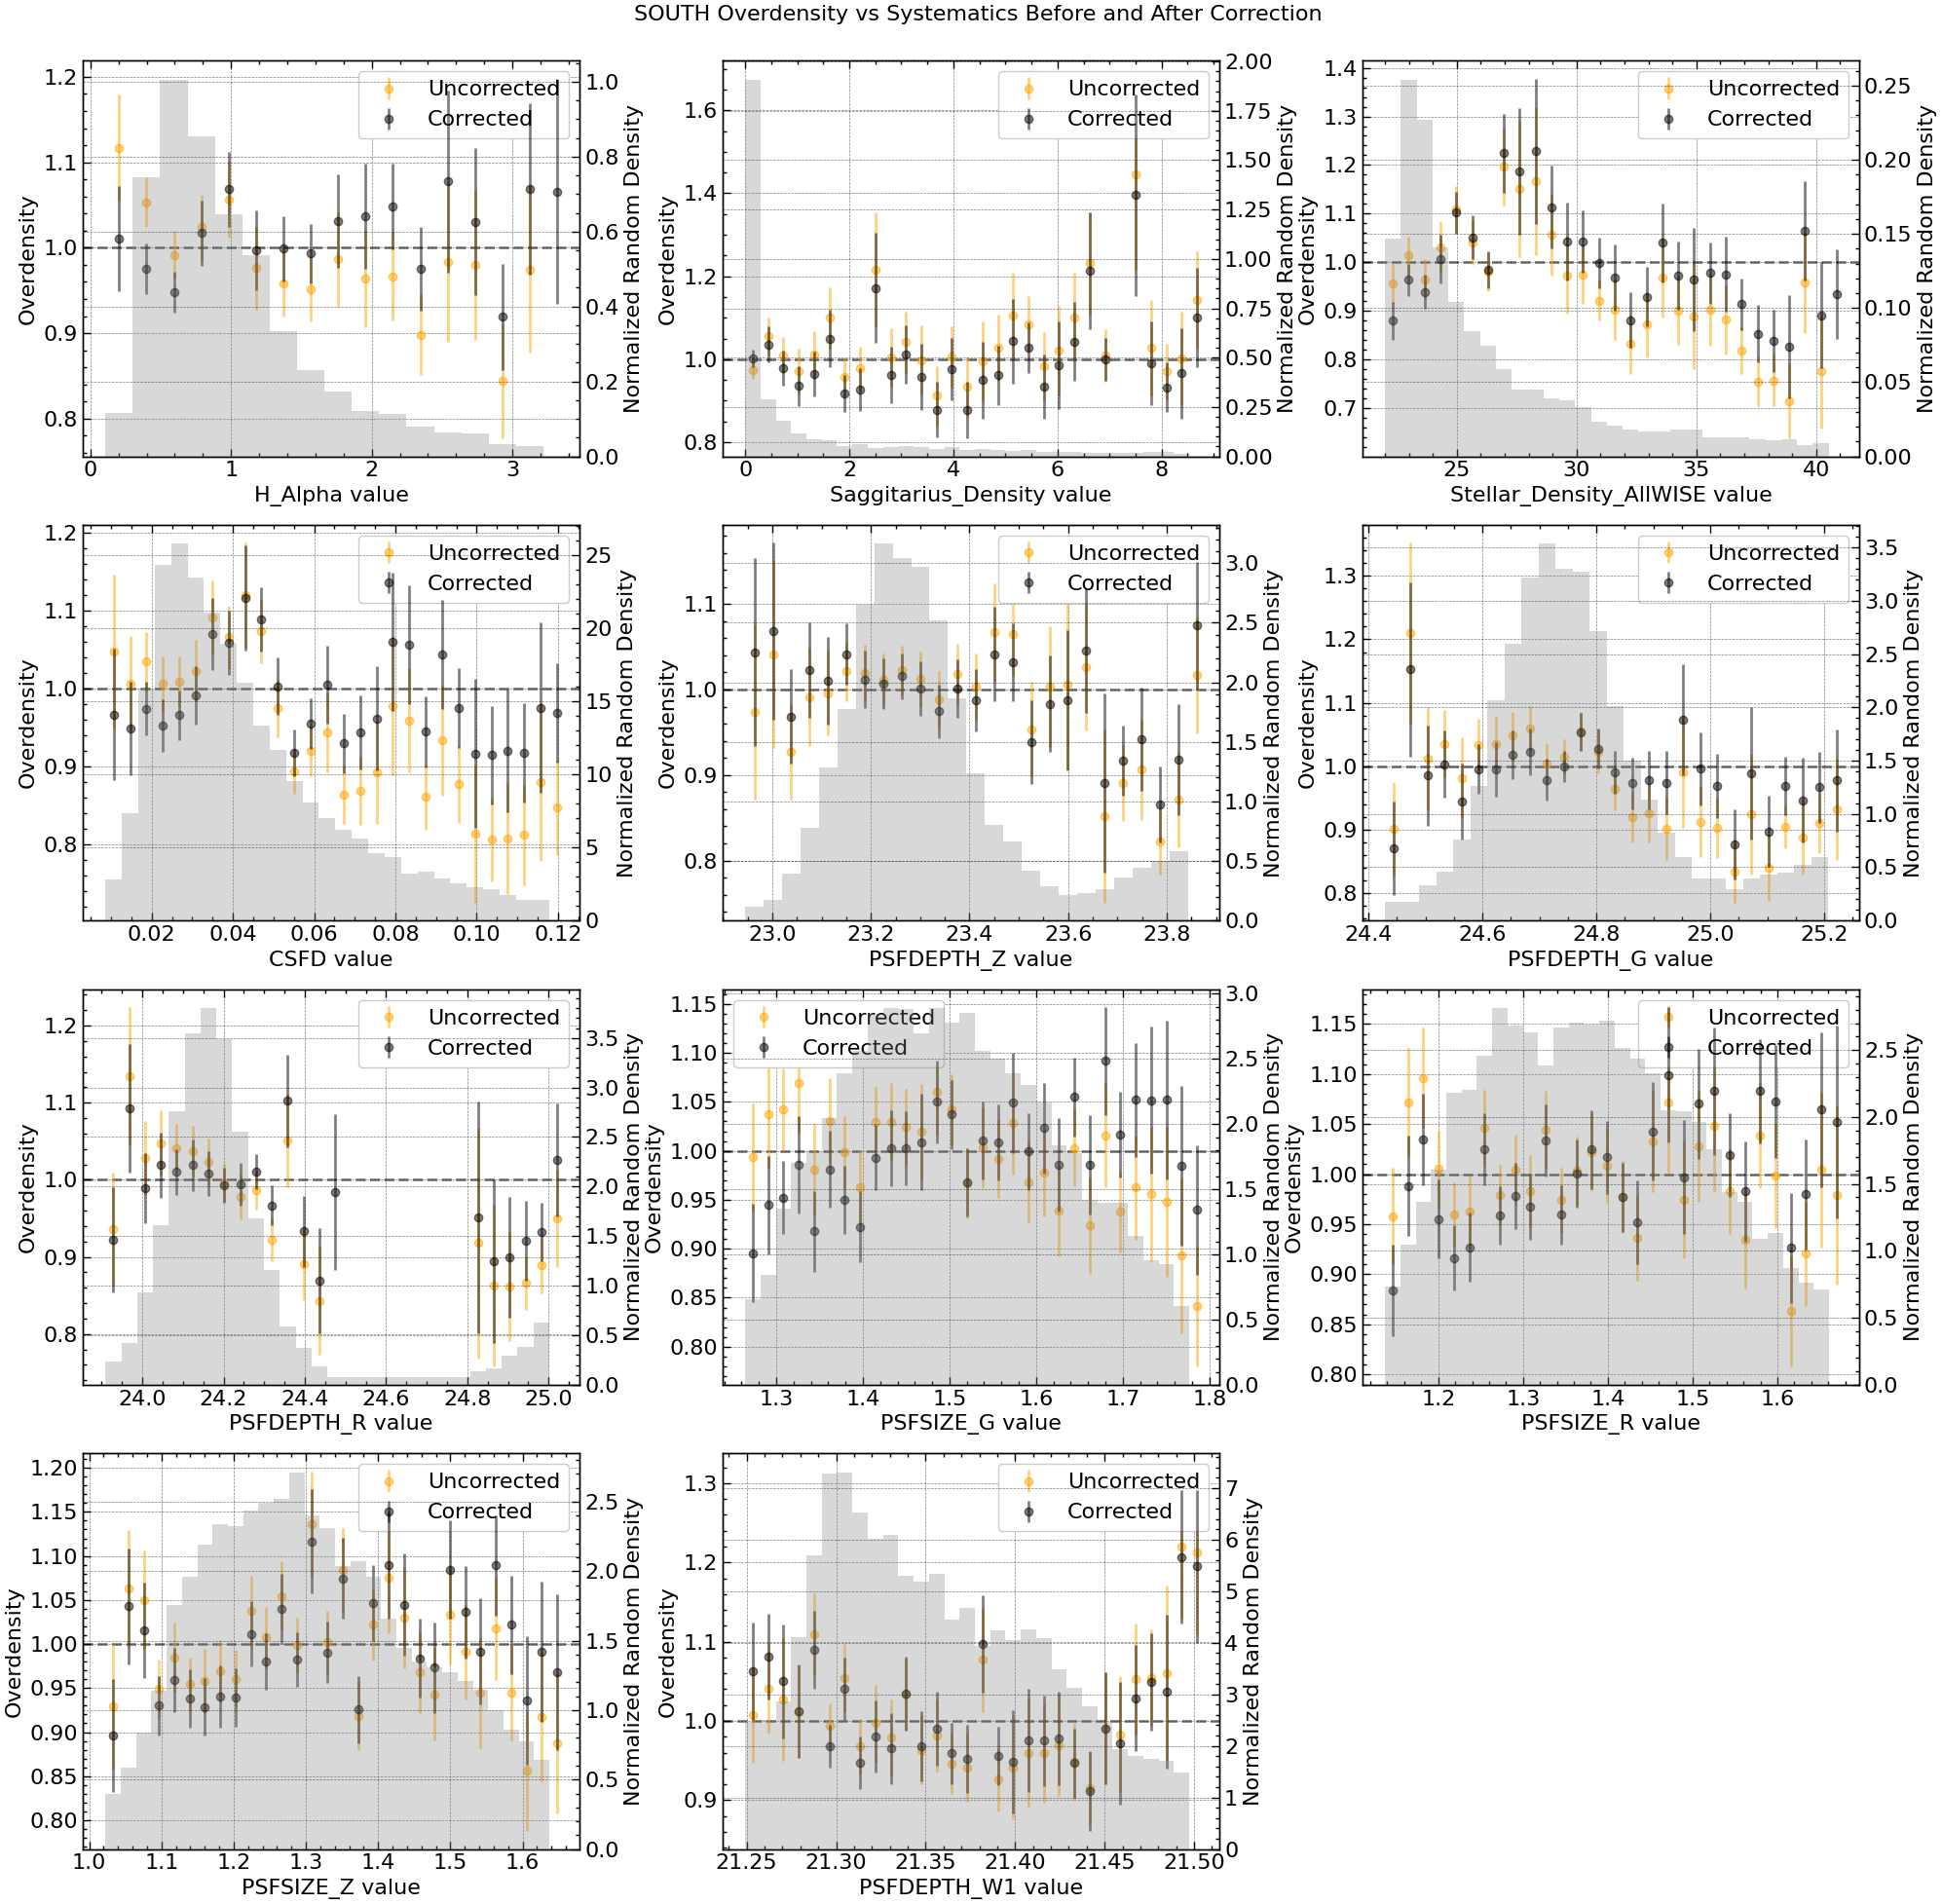

In [1497]:
binning  ='linear'
nbins = 30

n_sys = len(systematics_list)
n_cols = 3
n_rows = (n_sys + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for sys_ix, sys_map_plot in enumerate(systematics_list):
    ax1 = axes[sys_ix]
    data  = sys_maps_for_fit[sys_map_plot]
    counts, bin_edges = np.histogram(data, bins=100,weights = nran_valid)
    frac_area = counts/np.sum(counts)
    bin_centers = (bin_edges[:-1]+bin_edges[1:])/2
    order = np.argsort(bin_centers)
    cumfrac = np.cumsum(frac_area[order])
    num_mask = np.zeros_like(frac_area, dtype=bool)

    num_mask[order] = (cumfrac >= 0.05) & (cumfrac <= 0.95)
    x_lo = bin_edges[:-1][num_mask].min()
    x_hi = bin_edges[1:][num_mask].max()
    percentile_masking   = (data >= x_lo) & (data <= x_hi)
    
    bin_centers, full_vals, jk_err, data_full, rands_full, n_jack,bin_edges = error_jackknife_patch(
            ngal_valid, nran_valid, data,num_bins =nbins, nside=nside, ax=None,binning=binning,jk_labels=jk_labels_full
        )

    usable, bad_reasons = finalize_data(
                full_vals=full_vals,
                jk_err=jk_err,
                data_full=data_full,
                rands_full=rands_full,n_jack=n_jack)
    ax1.errorbar(bin_centers[usable], full_vals[usable], yerr=jk_err[usable], fmt='o', label=f'Uncorrected', zorder=5,alpha=0.5,color='orange')
    
    bin_centers, full_vals_corr, jk_err_corr, data_full_corr, rands_full, n_jack,bin_edges = error_jackknife_patch(
            ngal_corr_valid, nran_valid, data,num_bins =nbins, nside=nside, ax=None,binning=binning,jk_labels=jk_labels_full
        )

    usable, bad_reasons = finalize_data(
                full_vals=full_vals_corr,
                jk_err=jk_err_corr,
                data_full=data_full_corr,
                rands_full=rands_full,n_jack=n_jack)
    ax1.errorbar(bin_centers[usable], full_vals_corr[usable], yerr=jk_err_corr[usable], fmt='o', label=f'Corrected', zorder=10,alpha=0.5,color='k')
    ax1.axhline(y=1, color='k', linestyle='--', alpha=0.5)
    
    ax1.legend()
    ax2 = ax1.twinx()
    ax2.hist(data, bins=bin_edges[:-1][usable], weights=nran_valid, color='gray', alpha=0.3, label='Random-weighted footprint', density=True, zorder=0)
    ax2.set_ylabel('Normalized Random Density')
    ax1.set_xlabel(f'{sys_map_plot} value')
    ax1.set_ylabel('Overdensity')
    #ax1.set_title(f'{sys_map_plot}')

# Hide unused subplots
for idx in range(n_sys, len(axes)):
    axes[idx].axis('off')
# Hide unused subplots
for idx in range(n_sys, len(axes)):
    axes[idx].axis('off')

fig.suptitle(f'{part.upper()} Overdensity vs Systematics Before and After Correction', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [1498]:
data_full[-10:]

array([5320., 4671., 4005., 3857., 3001., 2996., 2905., 2865., 2868.,
       2702.])

In [1499]:
data_full_corr[-10:]

array([5327.70052499, 4628.47920799, 3959.95803863, 3830.10455859,
       2943.58124887, 2906.70595268, 2868.27072825, 2781.33078476,
       2816.46996462, 2645.28198549])

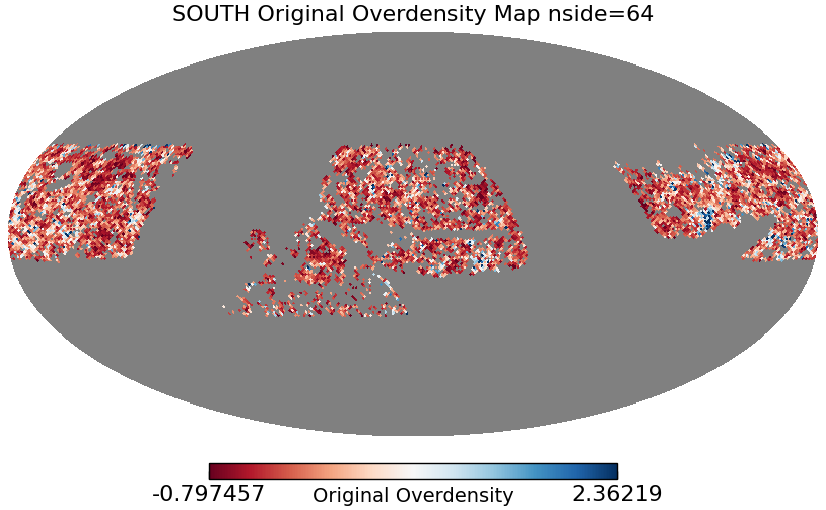

In [1500]:
hp.mollview(og_map, title=f'{part.upper()} Original Overdensity Map nside=64', unit='Original Overdensity', cmap='RdBu', min = np.percentile(y,1), max = np.percentile(y,99))

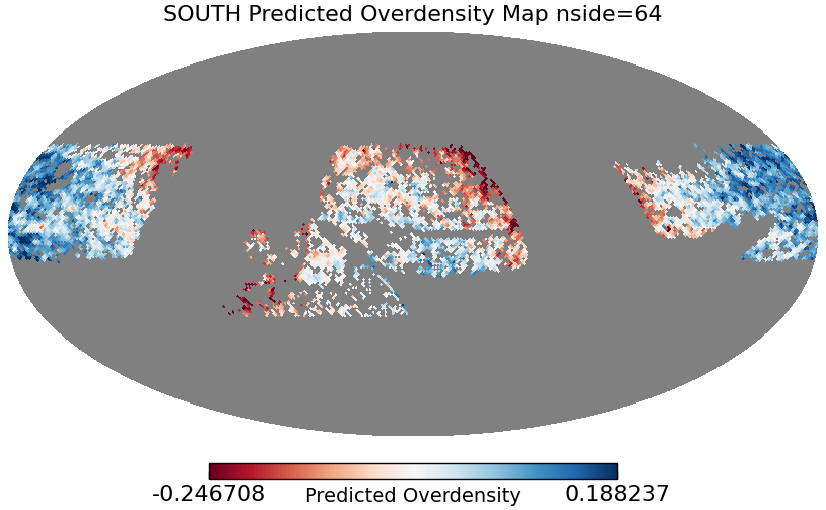

In [1501]:
hp.mollview(pred_map, title=f'{part.upper()} Predicted Overdensity Map nside=64', unit='Predicted Overdensity', cmap='RdBu', min = np.percentile(pred_overdens,1), max = np.percentile(pred_overdens,99))
if kind == 'equal':
    plt.savefig(f'{part}_predicted_overdensity_map_{kind}_{val}.png', dpi=300)
elif kind == 'partial_percentile':  
    plt.savefig(f'{part}_predicted_overdensity_map_{kind}.png', dpi=300)

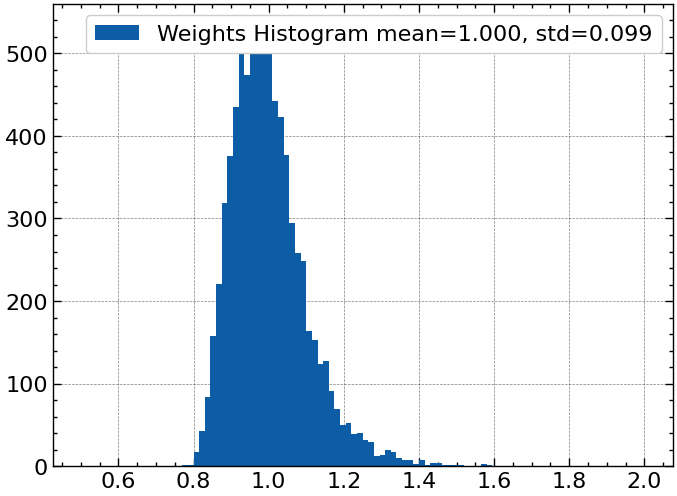

In [1502]:
plt.hist(weights,range=(0.5,2), bins=100,label=f'Weights Histogram mean={np.mean(weights):.3f}, std={np.std(weights):.3f}')
plt.legend()

In [1503]:
npix = hp.nside2npix(64)

pix_all = np.arange(npix)
pix_fit = pix_all[mask==1][combined_masks[mask==1]][valid][finite_mask_combined]

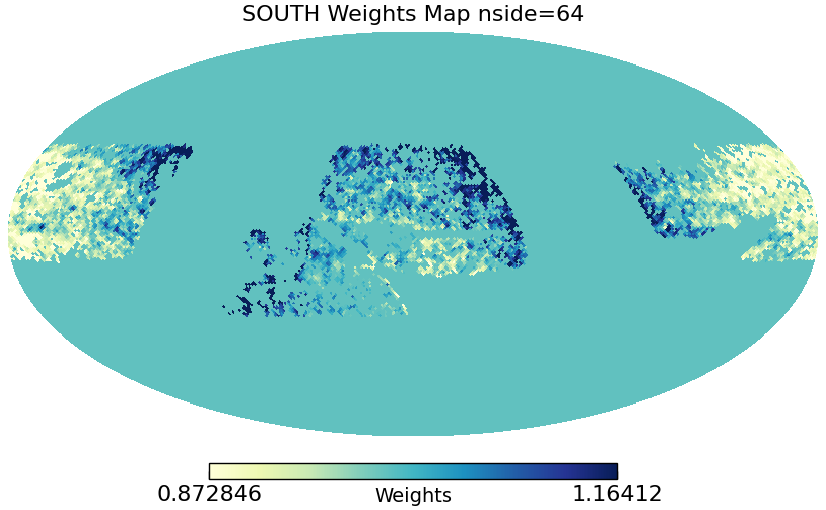

In [1504]:
wgt_map = np.ones(npix, dtype=float)
wgt_map[pix_fit] = weights
#hp.mollview(wgt_map, title=f'{part.upper()} Weights Map nside=64',cmap='YlGnBu', unit='Weights',)
hp.mollview(wgt_map, title=f'{part.upper()} Weights Map nside=64',cmap='YlGnBu', unit='Weights', min = np.nanpercentile(wgt_map, 1), max = np.nanpercentile(wgt_map, 99),)

In [1505]:
if kind == 'equal':
    hp.write_map(f'{part}_multilinear_systematic_weights_nside64_{kind}_{val}.fits', wgt_map,overwrite=True)
elif kind == 'partial_percentile':
    hp.write_map(f'{part}_multilinear_systematic_weights_nside64_{kind}.fits', wgt_map,overwrite=True)


setting the output map dtype to [dtype('float64')]


In [1506]:
# plt.figure(figsize=(10, 6))

# # Plot single point with error bar for outlier removed
# plt.errorbar(0.5,-4.581002, yerr=0.073759, fmt='o', color='orange', markersize=10, capsize=8, linewidth=2, label='With outlier removed at 90%')
# plt.errorbar(0.5, -3.784626, yerr=0.054305, fmt='o', color='blue', 
#              markersize=10, capsize=8, linewidth=2, label='With outlier removed at 95%')

# # Plot single point with error bar for full sample

# plt.errorbar(0.5,-3.575405, yerr=0.050154, fmt='o', color='green', markersize=10, capsize=8, linewidth=2, label='Outlier removed at 97.5%')
# plt.errorbar(0.5,  -2.570621, yerr=0.039467, fmt='o', color='red', 
#              markersize=10, capsize=8, linewidth=2, label='Full sample')
# plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
# plt.ylabel('Coefficient', fontsize=14)
# plt.title('Comparison of CSFD Coefficients South', fontsize=16)
# plt.legend(fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.xlim(0, 1)
# #plt.xticks([0.3, 0.7], ['With outlier removed', 'Full sample'], rotation=15)
# plt.tight_layout()
# plt.show()

In [1507]:
# plt.figure(figsize=(10, 6))

# # Plot single point with error bar for outlier removed
# plt.errorbar(0.5,4.287747, yerr=0.130490, fmt='o', color='orange', markersize=10, capsize=8, linewidth=2, label='With outlier removed at 90%')
# plt.errorbar(0.5, 2.246470, yerr=0.097064, fmt='o', color='blue', 
#              markersize=10, capsize=8, linewidth=2, label='With outlier removed at 95%')

# # Plot single point with error bar for full sample

# plt.errorbar(0.5, 0.683735, yerr=0.074361, fmt='o', color='green', markersize=10, capsize=8, linewidth=2, label='Outlier removed at 97.5%')
# plt.errorbar(0.5, -0.489374, yerr=0.060304, fmt='o', color='red', 
#              markersize=10, capsize=8, linewidth=2, label='Full sample')
# plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
# plt.ylabel('Coefficient', fontsize=14)
# plt.title('Comparison of CSFD Coefficients North', fontsize=16)
# plt.legend(fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.xlim(0, 1)
# #plt.xticks([0.3, 0.7], ['With outlier removed', 'Full sample'], rotation=15)
# plt.tight_layout()
# plt.show()

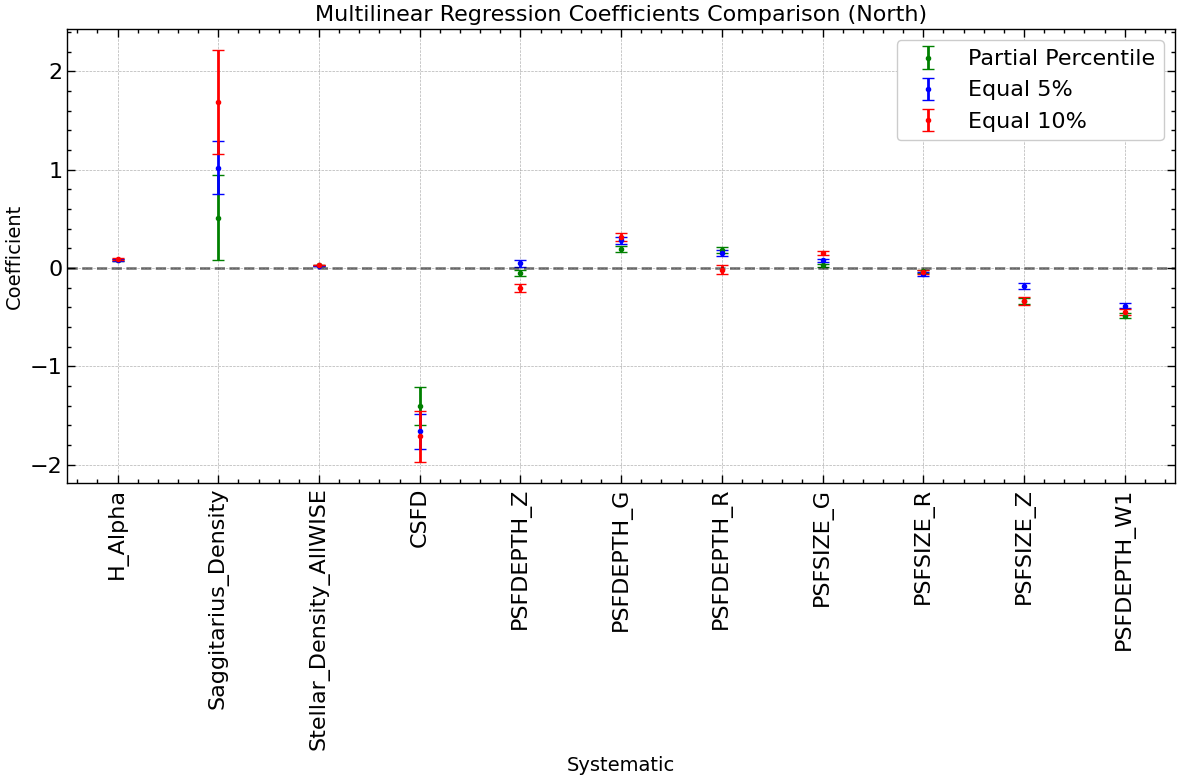

In [1510]:
part = 'north'
full_partial_percentile = f'{part}_multilinear_regression_coefficients_partial_percentile.npy'
full_equal_5 = f'{part}_multilinear_regression_coefficients_equal_5.npy'
full_equal_10 = f'{part}_multilinear_regression_coefficients_equal_10.npy'
plt.figure(figsize=(12, 8))
plt.errorbar(range(len(systematics_list)), np.load(full_partial_percentile, allow_pickle=True).item()['coefficients'], yerr=np.load(full_partial_percentile, allow_pickle=True).item()['errors'], 
             fmt='o', capsize=4, markersize=3, linewidth=2,color='g',label='Partial Percentile')
plt.errorbar(range(len(systematics_list)), np.load(full_equal_5, allow_pickle=True).item()['coefficients'], yerr=np.load(full_equal_5, allow_pickle=True).item()['errors'], 
             fmt='o', capsize=4, markersize=3, linewidth=2,color='b',label='Equal 5%')
plt.errorbar(range(len(systematics_list)), np.load(full_equal_10,   allow_pickle=True).item()['coefficients'], yerr=np.load(full_equal_10, allow_pickle=True).item()['errors'], 
             fmt='o', capsize=4, markersize=3, linewidth=2,color='r',label='Equal 10%')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xticks(range(len(systematics_list)), systematics_list, rotation=90)
plt.ylabel('Coefficient', fontsize=14)
plt.xlabel('Systematic', fontsize=14)
plt.title(f'Multilinear Regression Coefficients Comparison ({part.capitalize()})', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
